# **Convolutional Neural Network for Covid-19 Detection using XRAY Images**

> This project serves as a learning experience, using what I've already learnt previously to build a simple but highly accurate CNN (Convolutional Neural Network) model to classify whether an XRAY image of the lungs has COVID/Viral Pneumonia/Lung Opacity (abnormal cloudyness in lungs) or Normal.

All the codes in this notebook with the exception of certain parts of visualizations are made without the use of GenAI, but written directly with references from the Documentation or Search Engines as the main purpose was learning PyTorch and CNN.



### **Imports**

In [1]:
import torch
from torchvision import transforms
import warnings
import numpy as np
import random
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
import pandas as pd
import torchvision.datasets as dset
import torchvision.utils as vutils
from torch.utils.data import random_split, DataLoader 

# Model
import torch.nn as nn
import torch.nn.functional as F


# EDA
import matplotlib.pyplot as plt
from PIL import Image

# Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)



Random Seed:  999


### **Check GPU Availability**

If you have a GPU, the output would show `Using device: cuda`, else `Using device: cpu`

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### **Import dataset**

This project uses a kaggle dataset, if you have your own dataset, feel free to import them yourself and comment out/delete the codes below.

In [3]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [4]:
# import kagglehub
# import shutil
# import os

# cache_path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
# project_data_path = "./dataset"

# # Create folder if it doesn't exist
# os.makedirs(project_data_path, exist_ok=True)

# # copy from cache to your project
# shutil.copytree(cache_path, project_data_path, dirs_exist_ok=True)

# print("Dataset copied to:", project_data_path)

### **Global Variables**

In [5]:
dataset_root = "./dataset/COVID-19_Radiography_Dataset"
batch_size = 64
workers = 2
ngpu = 1

### **Loading the dataset**

Masking would not be used, hence we're only the images folder to train the CNN. Masking is used separately by another task which I will not be doing.

In [6]:
# Create the dataset
dataset = ImageFolder(root=dataset_root,
                           transform=transforms.Compose([
                               transforms.ToTensor(),
                           ]),
                           is_valid_file=lambda path: os.path.basename(os.path.dirname(path)) == 'images') # Ignores Mask images, for simplicity
dataset

Dataset ImageFolder
    Number of datapoints: 21165
    Root location: ./dataset/COVID-19_Radiography_Dataset
    StandardTransform
Transform: Compose(
               ToTensor()
           )

### **Train Test Splitting the dataset images**

The dataset is split 80:20 for training and testing respectively

In [7]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

### **Create DataLoader**

DataLoader is like a manager that manages how the data is retrieved, it makes batching the data easy for the CNN to load with later.

In [8]:
# Create the dataloader
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=workers)

### **Exploratory Data Analysis**

#### **Bar chart to check for class imbalance**

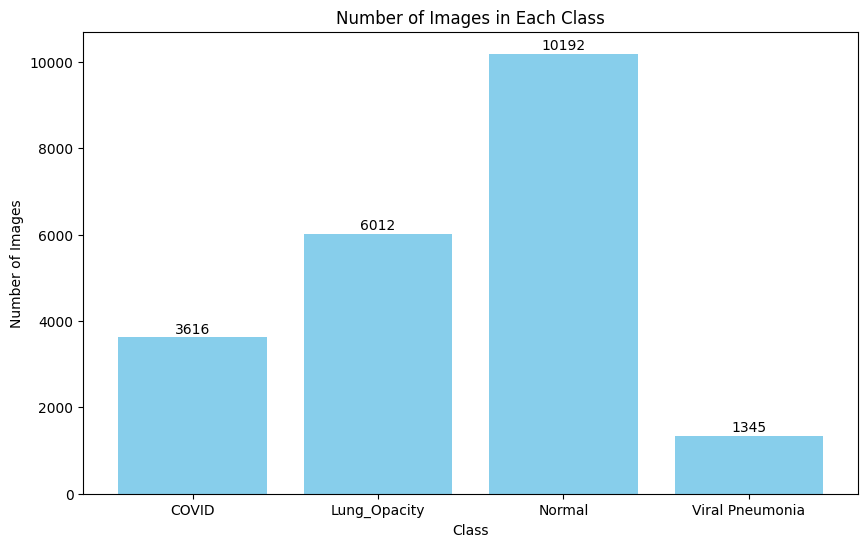

In [9]:
# The four classes in the dataset (for convenient plotting)
classes = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

# Stores the number of images for each class
counts = []


for class_name in classes:
    # Get the path to the images folder for this class
    image_folder = os.path.join(dataset_root, class_name, 'images')

    # Count the number of image files inside the folder
    count = len(os.listdir(image_folder))

    counts.append(count)

plt.figure(figsize=(10, 6))
plt.bar(classes, counts, color='skyblue')

plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Number of Images in Each Class')

# Showing the numbers above the bars
for i in range(len(classes)):
    plt.text(i, counts[i] + 100, counts[i], ha='center')


plt.show()

The bar chart shows an extremely imbalanced dataset which we'd have to handle later.

#### **Average image for each class**

Since the images in the directory are all already resized to 299x299, we do not have to take any actions to make sure their image size stays the same

In [10]:
# # Create a figure to show the average image for each class
# plt.figure(figsize=(14, 4))

# for i in range(len(classes)):
#     class_name = classes[i]

#     # Get the images folder for this class
#     image_folder = os.path.join(dataset_root, class_name, 'images')

#     # Get all image names in the folder
#     image_names = os.listdir(image_folder)

#     # Open the first image to get the image size
#     first_image_path = os.path.join(image_folder, image_names[0])
#     first_image = Image.open(first_image_path).convert('L')

#     # Create an empty image array to store the total pixel values
#     total_image = np.zeros(np.array(first_image).shape)

#     # Add all images in the class together
#     for image_name in image_names:
#         # Open the image and convert it to grayscale
#         image_path = os.path.join(image_folder, image_name)
#         image = Image.open(image_path).convert('L')

#         # Convert the image into a numpy array
#         image_array = np.array(image)

#         # Add this image's pixel values to the total
#         total_image = total_image + image_array

#     # Divide by the number of images to get the average image
#     average_image = total_image / len(image_names)

#     # Plot the average image for this class
#     plt.subplot(1, 4, i + 1)
#     plt.imshow(average_image, cmap='gray')
#     plt.title(class_name)
#     plt.axis('off')

# # Add the main title and show the plot
# plt.suptitle('Average Image for Each Class')
# plt.show()

The images seem to all show little to no differences across each other though there are subtle differences in lightness.

### **Creating the CNN model**

Here i created a fully connected CNN model with the classic order of Conv2D -> BatchNorm -> ReLU -> MaxPool2D. 

I used 2 layers of this for more features to be captured as seen from the previous EDA, the differences are subtle. 

AdapativeAvgPool2d is used to adaptively output the feature layer to 4x4, so that in the linear layer, the input shape would not need to be guessed, and any future changes to the model would be convenient without having to recalculate the shape.


Update (80% train accuracy):
- Reduced output channel size to reduce overfitting.
- Added Dropout to further reduce overfitting and improve generalization.
- Lowered output shape to 4x4 instead of 7 x 7 so its less powerful to overfit.

Update 2 (86% train accuracy):
- Increased output channel again as it became too weak
- Increased number of neuron units as to help increase accuracy

Update 3 (92.9% train accuracy):
- Reduced dropout in features, removed dropout from classifier (found it was hurting the model)
- Increased output shape to 6 x 6 to capture more features.

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Using Sequential as I do not intend to use connection skipping. This makes it
        # easier to make the forward propagation process much more convenient without needing 
        # to manually create new variables for each configuration added.
        self.features = nn.Sequential(
            nn.Conv2d(3, 20, 3, padding = 1),
            nn.BatchNorm2d(20),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(20, 40, 3, padding = 1),
            nn.BatchNorm2d(40),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(40, 80, 3, padding = 1),
            nn.BatchNorm2d(80),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(80, 80, 3, padding = 1),
            nn.BatchNorm2d(80),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2, 2),
            
            nn.AdaptiveAvgPool2d((6, 6))
        )
        
        # The part where the model actually "classifies"
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(80 * 6 * 6, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### **Adding weights for class imbalance**

Class weights is calculated by using the following formula:<br><br>
$
weight_i = \frac{Total \, Samples}{Total \, class \, \cdot \, count \, of \, sample_i}
$

This only works as we've already counted the number of samples previously in the bar chart above.


In [12]:
class_weights = torch.tensor([1 / count for count in counts]).to(device)

### **Training the CNN Model**

The model is moved to the appropriate device (GPU if available) using `.to(device)` to accelerate training. Input data and labels are also transferred to the same device to ensure compatibility.

For the loss function, `CrossEntropyLoss` is used as this is a multi-class classification problem. This loss function operates on raw logits and internally applies `LogSoftmax`, making it suitable for classification tasks. Class weights are added into the loss function to help improve the class imbalance we have witnessed prior.

The Adam optimizer is selected due to its adaptive learning rate mechanism, which generally leads to faster and more stable convergence compared to traditional optimizers such as stochastic gradient descent.

The model is trained on 30 epochs, which is a balanced number of epochs for time and accuracy. In the output we can see the loss has improved to a considerable amount by the time it reached around the 9th epoch. Further training can further push the model's accuracy.

Epoch 1 Loss: 0.6193 | accuracy: 38.07%
Epoch 2 Loss: 0.4065 | accuracy: 59.35%
Epoch 3 Loss: 0.3252 | accuracy: 67.48%
Epoch 4 Loss: 0.2777 | accuracy: 72.23%
Epoch 5 Loss: 0.2540 | accuracy: 74.60%
Epoch 6 Loss: 0.2230 | accuracy: 77.70%
Epoch 7 Loss: 0.2119 | accuracy: 78.81%
Epoch 8 Loss: 0.1900 | accuracy: 81.00%
Epoch 9 Loss: 0.1878 | accuracy: 81.22%
Epoch 10 Loss: 0.1696 | accuracy: 83.04%
Epoch 11 Loss: 0.1568 | accuracy: 84.32%
Epoch 12 Loss: 0.1507 | accuracy: 84.93%
Epoch 13 Loss: 0.1436 | accuracy: 85.64%
Epoch 14 Loss: 0.1544 | accuracy: 84.56%
Epoch 15 Loss: 0.1451 | accuracy: 85.49%
Epoch 16 Loss: 0.1270 | accuracy: 87.30%
Epoch 17 Loss: 0.1177 | accuracy: 88.23%
Epoch 18 Loss: 0.1195 | accuracy: 88.05%
Epoch 19 Loss: 0.1282 | accuracy: 87.18%
Epoch 20 Loss: 0.1081 | accuracy: 89.19%
Epoch 21 Loss: 0.1025 | accuracy: 89.75%
Epoch 22 Loss: 0.1030 | accuracy: 89.70%
Epoch 23 Loss: 0.0949 | accuracy: 90.51%
Epoch 24 Loss: 0.0934 | accuracy: 90.66%
Epoch 25 Loss: 0.0954 | a

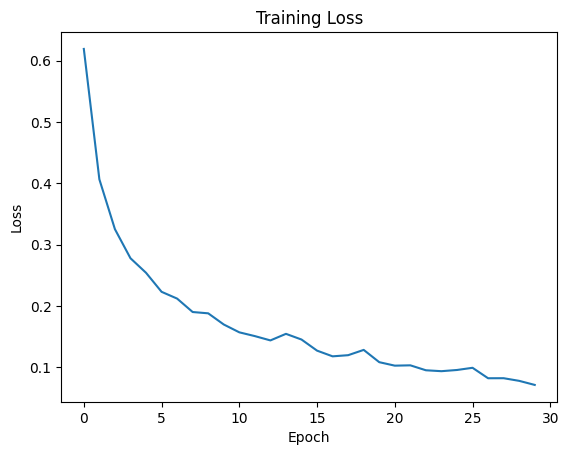

In [13]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

losses = []

for epoch in range(1, 31):
    epoch_loss = 0

    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    losses.append(avg_loss)

    print(f"Epoch {epoch} Loss: {avg_loss:.4f} | accuracy: {((1 - avg_loss)*100):.2f}%")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


### **Model Accuracy**

Here we assess the model's accuracy on the test data using the `test_dataloader`. We get to see the average accuracy the model performs on unseen data.

In [14]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for sample, label in test_dataloader:
        sample = sample.to(device)
        label = label.to(device)

        output = model(sample)
        predicted = torch.argmax(output, dim=1)
        
        correct += (predicted == label).sum().item()
        total += label.size(0)


accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9093


The model performs well, which explains as the resolution was high and 4 conv layers were used, which extracted a lot of features that may not be able to be seen by the naked eye.

### **Checking model prediction**

#### Selecting a random dataset image

In [20]:
# Random dataset image
random_index = random.randint(0, len(dataset)-1)
sample, true_label = dataset[random_index]

sample_batch = sample.unsqueeze(0).to(device)

prediction = model(sample_batch)
predicted_class = torch.argmax(prediction, dim=1).item()

classes = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


#### Result display

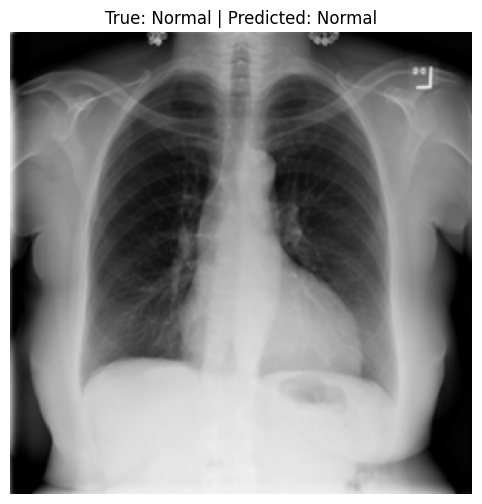

True Label: Normal
Predicted Label: Normal


In [21]:
# Display image and predictions
plt.figure(figsize=(8, 6))
img_display = sample.permute(1, 2, 0).cpu().numpy()
plt.imshow(img_display, cmap='gray')
plt.title(f"True: {classes[true_label]} | Predicted: {classes[predicted_class]}")
plt.axis('off')
plt.show()

print(f"True Label: {classes[true_label]}")
print(f"Predicted Label: {classes[predicted_class]}")

Success! Prediction looks correct.

### **Checking for class bias**

Here we use SkLearn's Classification Report to confirm if the high accuracy is a biased one or a real, reliable model that is able to consistently predict all classes well.

In [17]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       725
           1       0.85      0.87      0.86      1226
           2       0.92      0.90      0.91      2033
           3       0.94      0.99      0.96       249

    accuracy                           0.91      4233
   macro avg       0.92      0.93      0.93      4233
weighted avg       0.91      0.91      0.91      4233

[[ 707    9    8    1]
 [   6 1066  153    1]
 [  14  176 1830   13]
 [   0    0    3  246]]


Confusion matrix shows that class 1 (Lung Capacity) is slightly less accurate compared to the rest, however the overall performance is quite solid.

## **Key Takeaways**

- Use PyTorch to create a high accuracy CNN model without the use of GenAI generated codes.
- The process and usage reason for every line of code.
- Methods to improve CNN model performance.
- Documentation reading
- Debugging
- Tuning a CNN model logically based on output (time trained + performance)
- Using generalization techniques to prevent overfitting